<a href="https://colab.research.google.com/github/Pradss789/Prediksi-Customer-Churn/blob/main/naive_bayes_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Mining Prediksi Customer Churn
## Metode: Naive Bayes

**Dataset:** E-Commerce Customer Churn  
**Target:** Kolom `Churn` (1 = pelanggan berhenti, 0 = pelanggan aktif)



---
## Langkah 1 (Import Library)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport!')

Library berhasil diimport!


---
## Langkah 2 (Load dan Cek Data)



In [2]:
df = pd.read_csv('data_ecommerce_customer_churn.csv')

print('Ukuran data:', df.shape)
print()
df.head()

Ukuran data: (3941, 11)



,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


In [3]:
# Cek tipe data dan nilai kosong
print('Tipe data dan jumlah nilai kosong:')
print()
print(pd.DataFrame({
    'Tipe Data'    : df.dtypes,
    'Nilai Kosong' : df.isnull().sum()
}))

Tipe data dan jumlah nilai kosong:

                         Tipe Data  Nilai Kosong
Tenure                     float64           194
WarehouseToHome            float64           169
NumberOfDeviceRegistered     int64             0
PreferedOrderCat            object             0
SatisfactionScore            int64             0
MaritalStatus               object             0
NumberOfAddress              int64             0
Complain                     int64             0
DaySinceLastOrder          float64           213
CashbackAmount             float64             0
Churn                        int64             0


In [4]:
# Statistik ringkas
df.describe().round(2)

,Tenure,WarehouseToHome,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
count,3747.00,3772.00,3941.00,3941.00,3941.00,3941.00,3728.00,3941.00,3941.00
mean,10.08,15.65,3.68,3.09,4.24,0.28,4.53,176.71,0.17
std,8.50,8.45,1.01,1.38,2.63,0.45,3.67,48.79,0.38
min,0.00,5.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00
25%,2.00,9.00,3.00,2.00,2.00,0.00,2.00,145.70,0.00
50%,9.00,14.00,4.00,3.00,3.00,0.00,3.00,163.34,0.00
75%,16.00,21.00,4.00,4.00,6.00,1.00,7.00,195.25,0.00
max,61.00,127.00,6.00,5.00,22.00,1.00,46.00,324.99,1.00


---
## Langkah 3 (Eksplorasi Data (EDA))

In [5]:
# Jumlah pelanggan churn vs tidak churn
print('Distribusi kelas Churn:')
print(df['Churn'].value_counts())
print()
print('Dalam persen:')
print(df['Churn'].value_counts(normalize=True).mul(100).round(1).astype(str) + '%')

Distribusi kelas Churn:
Churn
0    3267
1     674
Name: count, dtype: int64

Dalam persen:
Churn
0    82.9%
1    17.1%
Name: proportion, dtype: object


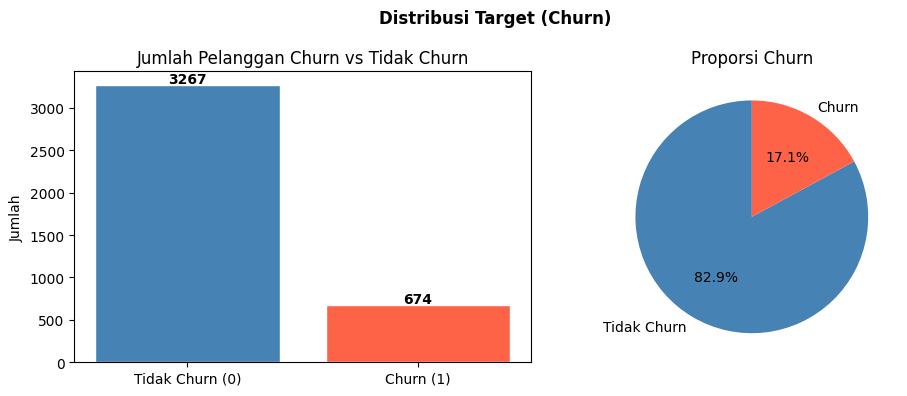

In [6]:
# Visualisasi distribusi target
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['Churn'].value_counts()
axes[0].bar(['Tidak Churn (0)', 'Churn (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='white')
axes[0].set_title('Jumlah Pelanggan Churn vs Tidak Churn')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=['Tidak Churn', 'Churn'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'],
            startangle=90)
axes[1].set_title('Proporsi Churn')

plt.suptitle('Distribusi Target (Churn)', fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# Perbandingan rata-rata fitur numerik antara churn dan tidak churn
num_cols = ['Tenure', 'WarehouseToHome', 'NumberOfDeviceRegistered',
            'SatisfactionScore', 'NumberOfAddress', 'DaySinceLastOrder', 'CashbackAmount']

means = df.groupby('Churn')[num_cols].mean().T
means.columns = ['Tidak Churn', 'Churn']

print('Rata-rata fitur numerik per kelas:')
print(means.round(2))

Rata-rata fitur numerik per kelas:
                          Tidak Churn   Churn
Tenure                          11.43    3.16
WarehouseToHome                 15.38   17.06
NumberOfDeviceRegistered         3.63    3.92
SatisfactionScore                3.02    3.42
NumberOfAddress                  4.19    4.46
DaySinceLastOrder                4.80    3.23
CashbackAmount                 180.29  159.36


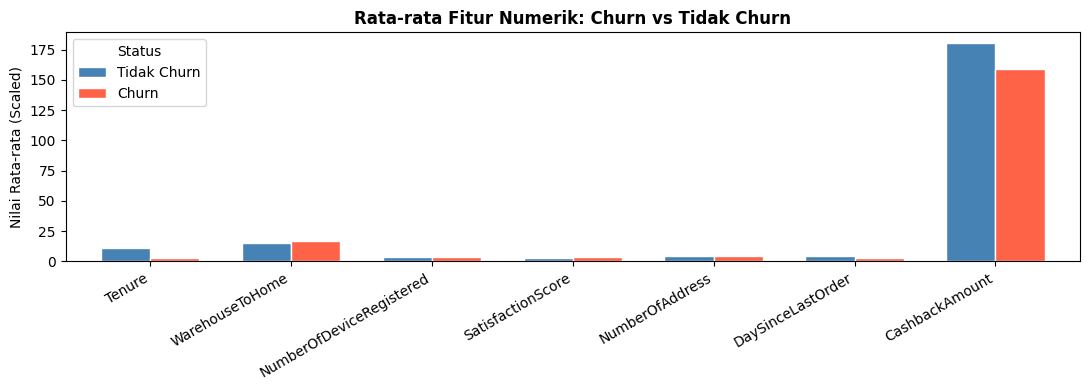

In [8]:
# Grafik perbandingan rata-rata
means.plot(kind='bar', figsize=(11, 4), color=['steelblue', 'tomato'],
           edgecolor='white', width=0.7)
plt.title('Rata-rata Fitur Numerik: Churn vs Tidak Churn', fontweight='bold')
plt.ylabel('Nilai Rata-rata (Scaled)')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Status')
plt.tight_layout()
plt.show()

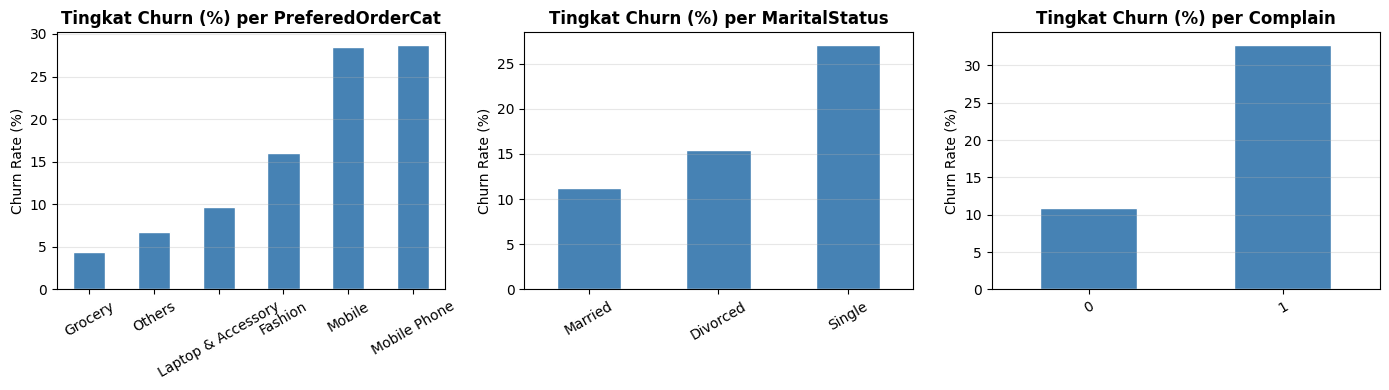

In [9]:
# Tingkat churn berdasarkan fitur kategorikal
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

cat_cols = ['PreferedOrderCat', 'MaritalStatus', 'Complain']
for ax, col in zip(axes, cat_cols):
    ct = df.groupby(col)['Churn'].mean() * 100
    ct.sort_values().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Tingkat Churn (%) per {col}', fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

---
## Langkah 4 (Preprocessing)

Preprocessing yang dilakukan:
1. **Isi nilai kosong** dengan nilai median
2. **Ubah kolom teks** menjadi angka (Label Encoding)
3. **Normalisasi** fitur numerik (Standard Scaling)

In [10]:
# Salin data agar data asli tidak berubah
data = df.copy()

# Isi nilai kosong dengan median
for col in ['Tenure', 'WarehouseToHome', 'DaySinceLastOrder']:
    data[col].fillna(data[col].median(), inplace=True)

print('Nilai kosong setelah diisi:', data.isnull().sum().sum())

Nilai kosong setelah diisi: 0


In [11]:
# Ubah kolom teks menjadi angka
le = LabelEncoder()
data['PreferedOrderCat'] = le.fit_transform(data['PreferedOrderCat'])
data['MaritalStatus']    = le.fit_transform(data['MaritalStatus'])

print('Data setelah encoding:')
data.head()

Data setelah encoding:


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,2,3,2,2,0,7.0,143.32,0
1,7.0,25.0,4,3,1,1,2,0,7.0,129.29,0
2,27.0,13.0,3,2,1,1,5,0,7.0,168.54,0
3,20.0,25.0,4,0,3,0,7,0,3.0,230.27,0
4,30.0,15.0,4,5,4,2,8,0,8.0,322.17,0


In [12]:
# Pisahkan fitur (X) dan target (y)
X = data.drop(columns=['Churn'])
y = data['Churn']

# Bagi data: 80% latih, 20% uji
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Data latih : {len(X_train)} baris')
print(f'Data uji   : {len(X_test)} baris')

Data latih : 3152 baris
Data uji   : 789 baris


In [13]:
# Normalisasi fitur
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print('Normalisasi selesai.')

Normalisasi selesai.


---
## Langkah 5 (Membuat Model Naive Bayes)

In [14]:
# Buat dan latih model Gaussian Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

print('Model selesai dilatih!')
print()
print('Probabilitas awal tiap kelas (prior):')
print(f'  Tidak Churn (0) : {model.class_prior_[0]:.4f} ({model.class_prior_[0]*100:.1f}%)')
print(f'  Churn (1)       : {model.class_prior_[1]:.4f} ({model.class_prior_[1]*100:.1f}%)')

Model selesai dilatih!

Probabilitas awal tiap kelas (prior):
  Tidak Churn (0) : 0.8290 (82.9%)
  Churn (1)       : 0.1710 (17.1%)


---
## Langkah 6 (Evaluasi Model)

In [15]:
# Prediksi pada data uji
y_pred = model.predict(X_test)

# Hitung metrik evaluasi
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print('=======================================')
print('   HASIL EVALUASI MODEL NAIVE BAYES')
print('=======================================')
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print('=======================================')

   HASIL EVALUASI MODEL NAIVE BAYES
  Accuracy  : 85.80%
  Precision : 58.39%
  Recall    : 59.26%
  F1-Score  : 58.82%


In [16]:
# Laporan klasifikasi lengkap
print(classification_report(y_test, y_pred,
      target_names=['Tidak Churn', 'Churn']))

              precision    recall  f1-score   support

 Tidak Churn       0.92      0.91      0.91       654
       Churn       0.58      0.59      0.59       135

    accuracy                           0.86       789
   macro avg       0.75      0.75      0.75       789
weighted avg       0.86      0.86      0.86       789



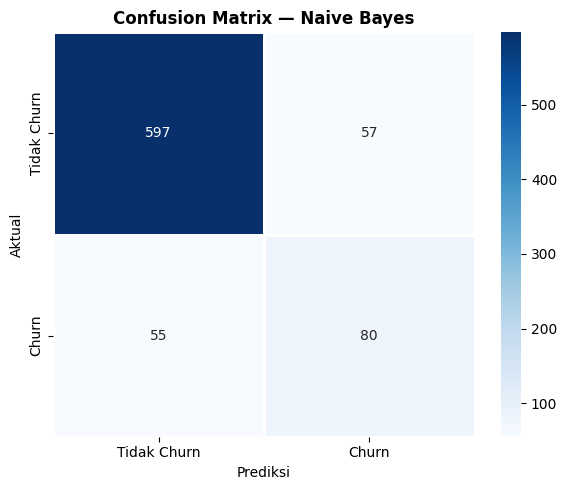

True Negative  (TN) = 597  → prediksi tidak churn, aktual tidak churn (benar)
False Positive (FP) = 57  → prediksi churn, aktual tidak churn (salah)
False Negative (FN) = 55  → prediksi tidak churn, aktual churn (salah)
True Positive  (TP) = 80  → prediksi churn, aktual churn (benar)


In [17]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Tidak Churn', 'Churn'],
            yticklabels=['Tidak Churn', 'Churn'],
            linewidths=1)
plt.title('Confusion Matrix — Naive Bayes', fontweight='bold')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negative  (TN) = {tn}  → prediksi tidak churn, aktual tidak churn (benar)')
print(f'False Positive (FP) = {fp}  → prediksi churn, aktual tidak churn (salah)')
print(f'False Negative (FN) = {fn}  → prediksi tidak churn, aktual churn (salah)')
print(f'True Positive  (TP) = {tp}  → prediksi churn, aktual churn (benar)')

---
## Langkah 7 (Interpretasi Hasil)

In [18]:
# Lihat contoh prediksi beserta probabilitasnya
y_prob = model.predict_proba(X_test)[:, 1]

# Ambil 10 contoh
contoh = pd.DataFrame({
    'Aktual'      : ['Churn' if v == 1 else 'Tidak Churn' for v in y_test.values[:10]],
    'Prediksi'    : ['Churn' if v == 1 else 'Tidak Churn' for v in y_pred[:10]],
    'P(Churn)'    : y_prob[:10].round(3),
    'Keterangan'  : ['Benar' if a == p else 'Salah'
                     for a, p in zip(y_test.values[:10], y_pred[:10])]
})
print('Contoh Prediksi Model:')
print(contoh.to_string(index=False))

Contoh Prediksi Model:
     Aktual    Prediksi  P(Churn) Keterangan
Tidak Churn Tidak Churn     0.001      Benar
Tidak Churn Tidak Churn     0.041      Benar
Tidak Churn Tidak Churn     0.282      Benar
Tidak Churn Tidak Churn     0.065      Benar
Tidak Churn Tidak Churn     0.489      Benar
Tidak Churn Tidak Churn     0.000      Benar
Tidak Churn Tidak Churn     0.288      Benar
Tidak Churn Tidak Churn     0.002      Benar
Tidak Churn Tidak Churn     0.000      Benar
Tidak Churn Tidak Churn     0.082      Benar


In [19]:
# Ringkasan pola churn dari data asli
print('=== Pola Churn dari Data Asli ===')
print()
print('Rata-rata Tenure pelanggan:')
print(df.groupby('Churn')['Tenure'].mean().rename({0:'Tidak Churn', 1:'Churn'}).round(2))
print()
print('Rata-rata CashbackAmount:')
print(df.groupby('Churn')['CashbackAmount'].mean().rename({0:'Tidak Churn', 1:'Churn'}).round(2))
print()
print('Tingkat churn pelanggan yang komplain:')
print(df.groupby('Complain')['Churn'].mean().mul(100).round(1).rename({0:'Tidak Komplain', 1:'Komplain'}).astype(str) + '%')

=== Pola Churn dari Data Asli ===

Rata-rata Tenure pelanggan:
Churn
Tidak Churn    11.43
Churn           3.16
Name: Tenure, dtype: float64

Rata-rata CashbackAmount:
Churn
Tidak Churn    180.29
Churn          159.36
Name: CashbackAmount, dtype: float64

Tingkat churn pelanggan yang komplain:
Complain
Tidak Komplain    10.9%
Komplain          32.8%
Name: Churn, dtype: object


---
## Kesimpulan

### Hasil Model
Model Naive Bayes berhasil dibangun untuk memprediksi pelanggan yang akan churn.
Metrik evaluasi menunjukkan kemampuan model yang cukup baik sebagai pendekatan awal (*baseline*).

### Interpretasi Metrik
- **Accuracy** — persentase total prediksi yang benar dari seluruh data uji
- **Precision** — dari pelanggan yang *diprediksi* churn, berapa persen yang benar-benar churn
- **Recall** — dari pelanggan yang *sesungguhnya* churn, berapa persen yang berhasil terdeteksi
- **F1-Score** — rata-rata harmonis precision dan recall; berguna saat data tidak seimbang

### Temuan Utama dari Data
1. **Pelanggan baru lebih berisiko churn** — tenure yang pendek berkaitan erat dengan churn
2. **Komplain adalah sinyal kuat** — pelanggan yang pernah komplain memiliki churn rate jauh lebih tinggi
3. **Cashback berpengaruh positif** — pelanggan dengan cashback lebih besar cenderung bertahan

### Mengapa Naive Bayes Dipilih?
- Mudah dipahami karena berbasis probabilitas
- Tidak memerlukan banyak hyperparameter
- Cocok untuk klasifikasi biner seperti prediksi churn
- Hasil dapat dijelaskan dalam bentuk `P(Churn)` untuk tiap pelanggan